## OpenWillis acoustic feature extraction

In [1]:
import openwillis as ow

2026-06-18 15:31:20.289584: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-18 15:31:20.289662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-18 15:31:20.291530: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-18 15:31:20.301006: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 15:31:21.143047: W tensorflow/compiler/tf2

In [11]:
import pandas as pd
from pathlib import Path
import os

In [5]:
import pkgutil
modules = [m.name for m in pkgutil.iter_modules(ow.__path__)]
print(modules)

['face', 'gps', 'speech', 'transcribe', 'voice']


In [6]:
print(ow.__file__)

/home/luschroe/miniconda3/envs/openwillis/lib/python3.10/site-packages/openwillis/__init__.py


In [8]:
train = pd.read_csv("data/train_split_Depression_AVEC2017.csv")

labels = train[["Participant_ID", "PHQ8_Score"]]
labels["Participant_ID"] = labels["Participant_ID"].astype(str)

In [9]:
audio_files = list(Path("data").glob("*_AUDIO.wav"))

audio_files[:5]

[PosixPath('data/304_AUDIO.wav'),
 PosixPath('data/307_AUDIO.wav'),
 PosixPath('data/308_AUDIO.wav'),
 PosixPath('data/309_AUDIO.wav'),
 PosixPath('data/310_AUDIO.wav')]

In [ ]:
folder_path = "data/"

framewise_data = pd.DataFrame()
summary_data = pd.DataFrame()
turnwise_data = pd.DataFrame()

for filename in os.listdir(folder_path):
  if filename.endswith('.wav'):
    audio_path = os.path.join(folder_path, filename)

    # Run vocal acoustics function
    framewise, turnwise, summary = ow.vocal_acoustics(audio_path = audio_path, voiced_segments = False, option = 'simple')
    # change to owv.vocal_acoustics if working from openwillis-voice instead of openwillis

    # Here, make sure we can identify each file by adding the name in the first column of the dataframe, remove '.wav' from the name
    filename_no_ext = os.path.splitext(filename)[0]

    # Add filename column as the first column using insert()
    framewise.insert(0, 'filename', filename_no_ext)
    turnwise.insert(0, 'filename', filename_no_ext)
    summary.insert(0, 'filename', filename_no_ext)

    # Store results for each file in each dataframe
    framewise_data = pd.concat([framewise_data, framewise], ignore_index=True)
    turnwise_data = pd.concat([framewise_data, framewise], ignore_index=True)
    summary_data = pd.concat([summary_data, summary], ignore_index=True)

In [25]:
summary_data.head()

,filename,f0_mean,f0_stddev,f0_range,f1_mean,f1_stddev,f1_range,f2_mean,f2_stddev,f2_range,...,cpp_kurtosis,cpp_skewness,spectral_variability,lhr_mean,lhr_var,lhr_kurtosis,lhr_skewness,acf1,acf2,acf3
0,304_AUDIO,207.472289,54.318178,423.842736,668.392502,361.475107,2459.571992,1914.633381,354.623539,3552.477429,...,1.272770,1.270656,10.949562,18.209970,399.399945,9.672804,2.743179,17.999770,4.188043e-07,4.137896e-09
1,307_AUDIO,207.116232,64.223614,425.022279,589.200504,195.051260,2141.384437,1670.515555,414.610212,3488.286084,...,0.201061,0.949274,14.557343,56.000507,2332.131322,5.778778,1.946933,17.998714,2.484834e-07,4.099365e-09
2,308_AUDIO,175.368761,62.701366,424.956673,594.839363,219.742938,2320.807609,1559.238502,426.642993,3550.785624,...,1.660484,0.709921,5.438141,33.950178,624.667571,14.110080,3.046277,17.999879,3.877534e-07,5.510288e-09
3,309_AUDIO,125.201956,19.432663,400.861384,890.395229,400.723293,2575.166280,2005.254521,455.490543,3879.558812,...,2.784976,1.832557,16.776058,22.735274,1337.157805,112.272672,6.047499,17.976183,2.732737e-04,2.297270e-06
4,310_AUDIO,93.112803,37.885770,424.239471,941.746765,447.354020,2964.967508,2050.520909,487.337456,3808.713643,...,2.236684,1.559823,15.716138,21.668888,1199.439535,77.636987,6.705604,17.999916,6.760406e-07,1.197076e-08


In [26]:
output_dir = './' # can change to a different output path if desired
output_filename = 'summary_data.csv'
output_csv_path = os.path.join(output_dir, output_filename)

summary_data.to_csv(output_csv_path, index = False)

In [33]:
framewise_data.head()

,filename,f0,f1,f2,f3,f4,loudness,hnr
0,304_AUDIO,0.0,997.428187,2449.468665,3206.152328,4493.352825,37.254814,NaN
1,304_AUDIO,0.0,406.976627,1492.157352,2802.652681,3860.152853,36.766127,NaN
2,304_AUDIO,0.0,882.185761,2459.627968,3640.798486,4791.250013,36.342926,NaN
3,304_AUDIO,0.0,862.214348,2223.104241,3211.452564,4414.322709,34.323457,NaN
4,304_AUDIO,0.0,781.603953,2178.275021,3271.636353,4421.200104,34.034360,NaN


In [27]:
import matplotlib.pyplot as plt
import numpy as np

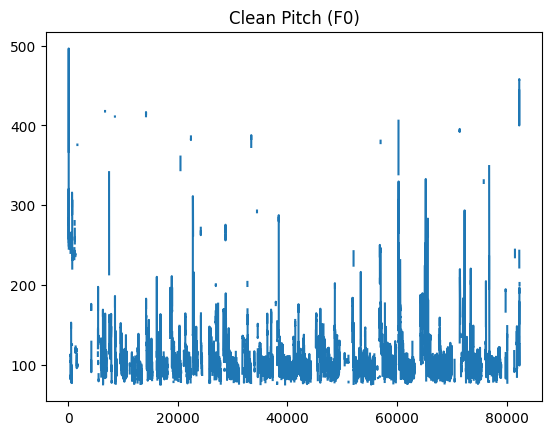

In [29]:
f0_clean = framewise["f0"].replace(0, np.nan)

plt.figure()
plt.plot(f0_clean)
plt.title("Clean Pitch (F0)")
plt.show()

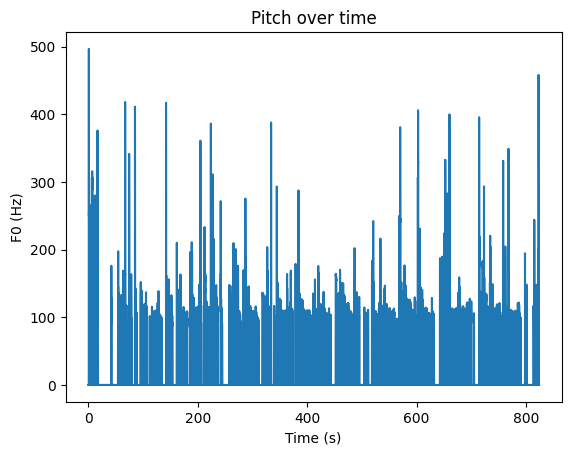

In [30]:
sr = 100  # oft 10ms frame shift → 100 fps (approx)
time = np.arange(len(framewise)) / sr

plt.figure()
plt.plot(time, framewise["f0"])
plt.xlabel("Time (s)")
plt.ylabel("F0 (Hz)")
plt.title("Pitch over time")
plt.show()